In [8]:
import math
import random
import torch
from torch import Tensor, nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from pathlib import Path

SEED = 7
DATA_DIR = Path('shakespeare-dataset-main/text')
BLOCK_SIZE, BATCH_SIZE, NUM_WORKERS = 64, 128, 0
DIM, NUM_LAYERS, NUM_HEADS, FF_DIM, DROPOUT = 16, 6, 4, 512, 0.1
DIFFUSION_STEPS, BETA_START, BETA_END = 1000, 1e-4, 0.02
LEARNING_RATE, WEIGHT_DECAY, GRAD_CLIP_NORM = 3e-4, 1e-2, 1.0
TRAIN_STEPS, LOG_EVERY, SAMPLE_EVERY = 10_000, 50, 1_000
CE_WEIGHT, PRIOR_WEIGHT = 1.0, 10.0
PRIOR_SAMPLES, PRIOR_PROJECTIONS = 1_024, 32
SAMPLE_BATCH_SIZE, SAMPLE_REVERSE_STEPS = 2, 250
DDIM_ETA = 0.1  # 0 = deterministic; 0.1 = mild noise; supported range [0, 1].
SAMPLE_SEED = 1  # Local sampling RNG; fixed noise makes checkpoint samples comparable.

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
random.seed(SEED)
print(f'Using {device}')


Using mps


In [9]:
def clean_folger_text(raw):
    lines = raw.replace('\r\n', '\n').replace('\r', '\n').splitlines(keepends=True)
    return ''.join(lines[7:]).lstrip('\n')

paths = sorted(DATA_DIR.glob('*.txt'))
if not paths:
    raise FileNotFoundError(f'No .txt files in {DATA_DIR}')
text = '\n\n'.join(clean_folger_text(p.read_text(encoding='utf-8')) for p in paths)
chars = sorted(set(text))
stoi = {char: index for index, char in enumerate(chars)}
itos = dict(enumerate(chars))
tokens = torch.tensor([stoi[c] for c in text], dtype=torch.long)
token_probabilities = (torch.bincount(tokens, minlength=len(chars)) / len(tokens)).to(device)

class CharacterBlocks(Dataset):
    def __init__(self, values, block_size):
        self.values = values
        self.block_size = block_size
    def __len__(self): return len(self.values) // self.block_size
    def __getitem__(self, index):
        start = index * self.block_size
        return self.values[start:start + self.block_size]

dataset = CharacterBlocks(tokens, BLOCK_SIZE)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=NUM_WORKERS)
print(f'Loaded {len(paths)} works | {len(text):,} characters | vocab={len(chars)} | batch={tuple(next(iter(loader)).shape)}')


Loaded 42 works | 5,319,139 characters | vocab=84 | batch=(128, 64)


In [10]:
class GaussianEmbedding(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        token_var = 0.05
        mean_var = 1.0 - token_var

        std_init = math.sqrt(token_var)
        raw_std_init = math.log(math.expm1(std_init))

        self.mu = nn.Parameter(torch.randn(vocab_size, dim) * math.sqrt(mean_var))
        self.raw_std = nn.Parameter(torch.full((vocab_size, dim), raw_std_init))
    @property
    def std(self):
        return F.softplus(self.raw_std)
    def sample(self, ids):
        mean = self.mu[ids]
        return mean + self.std[ids] * torch.randn_like(mean)
    def log_probs(self, vectors):
        std = self.std
        precision = std.square().reciprocal()
        weighted_means = self.mu * precision
        mahalanobis = (
            vectors.square() @ precision.T
            - 2 * (vectors @ weighted_means.T)
            + (self.mu.square() * precision).sum(-1)
        )
        log_density = -0.5 * mahalanobis - std.log().sum(-1)
        return F.log_softmax(log_density, dim=-1)

# Model 
class SimpleGaussianDiffusionLM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = GaussianEmbedding(vocab_size, DIM)
        self.position = nn.Embedding(BLOCK_SIZE, DIM)

        frequencies = torch.exp(-math.log(10_000) * torch.arange(DIM // 2) / (DIM // 2))
        self.register_buffer('time_frequencies', frequencies)
        layer = nn.TransformerEncoderLayer(DIM, NUM_HEADS, FF_DIM, DROPOUT, batch_first=True, norm_first=False, activation='gelu')
        self.transformer = nn.TransformerEncoder(layer, NUM_LAYERS)
        self.final_norm, self.x0_head = nn.LayerNorm(DIM), nn.Linear(DIM, DIM)
    def forward(self, x_t, timesteps):
        pos = torch.arange(x_t.size(1), device=x_t.device)
        angles = timesteps[:, None] * self.time_frequencies
        time_embedding = torch.cat((angles.sin(), angles.cos()), dim=-1)
        hidden = x_t + self.position(pos).unsqueeze(0) + time_embedding.unsqueeze(1)
        return self.x0_head(self.final_norm(self.transformer(hidden)))
    def rounding_log_probs(self, vectors): return self.embedding.log_probs(vectors)
    def round_to_tokens(self, vectors): return self.rounding_log_probs(vectors).argmax(-1)

model = SimpleGaussianDiffusionLM(len(chars)).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')


Parameters: 112,400


In [11]:
betas = torch.linspace(BETA_START, BETA_END, DIFFUSION_STEPS, device=device)
alpha_bar = torch.cat((torch.ones(1, device=device), torch.cumprod(1 - betas, 0)))

def q_sample(x0, t):
    alpha = alpha_bar[t].view(-1, 1, 1)
    return alpha.sqrt() * x0 + (1 - alpha).sqrt() * torch.randn_like(x0)

def sliced_wasserstein_loss(x0):
    values = x0.reshape(-1, DIM)
    sample = values[torch.randperm(len(values), device=values.device)[:PRIOR_SAMPLES]]
    directions = F.normalize(torch.randn(DIM, PRIOR_PROJECTIONS, device=values.device), dim=0)
    projected = sample @ directions
    normal = torch.randn_like(projected)
    return (projected.sort(dim=0).values - normal.sort(dim=0).values).square().mean()


@torch.no_grad()
def embedding_diagnostics():
    probabilities = token_probabilities[:, None]
    means = model.embedding.mu
    variances = model.embedding.std.square()
    mean = (probabilities * means).sum(0)
    centered = means - mean
    between_covariance = (probabilities * centered).T @ centered
    within_diagonal = (probabilities * variances).sum(0)
    covariance = between_covariance + torch.diag(within_diagonal)
    return {
        'mean_avg': mean.mean().item(),
        'mean_rms': mean.square().mean().sqrt().item(),
        'variance_avg': covariance.diagonal().mean().item(),
        'within_variance': within_diagonal.mean().item(),
        'between_variance': between_covariance.diagonal().mean().item(),
        'cov_rms_error': (
            torch.linalg.matrix_norm(covariance - torch.eye(DIM, device=device))
            / math.sqrt(DIM)
        ).item(),
    }


def loss_terms(ids):
    # One Gaussian embedding draw and one denoising prediction per training example.
    x0 = model.embedding.sample(ids)
    t = torch.randint(1, DIFFUSION_STEPS + 1, (ids.size(0),), device=device)
    prediction = model(q_sample(x0, t), t)
    token_ce = F.nll_loss(
        model.rounding_log_probs(prediction).flatten(0, 1), ids.flatten()
    )
    weighted_prior = PRIOR_WEIGHT * sliced_wasserstein_loss(x0)
    # Uniform CE across timesteps; no MSE, clean-embedding CE, or detached embeddings.
    total = CE_WEIGHT * token_ce + weighted_prior
    return total, token_ce, weighted_prior


optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
completed_steps = 0  # Reset together with the optimizer; train() calls accumulate updates.

# Capture the configuration for this fresh run, rather than relying on the filename.
# After changing settings, rerun from the top to initialize a matching model/optimizer.
OBJECTIVE = 'noisy_token_ce_plus_sliced_wasserstein_prior'
CONFIG_NAMES = (
    'SEED', 'DATA_DIR', 'BLOCK_SIZE', 'BATCH_SIZE', 'NUM_WORKERS',
    'DIM', 'NUM_LAYERS', 'NUM_HEADS', 'FF_DIM', 'DROPOUT',
    'DIFFUSION_STEPS', 'BETA_START', 'BETA_END',
    'LEARNING_RATE', 'WEIGHT_DECAY', 'GRAD_CLIP_NORM',
    'TRAIN_STEPS', 'LOG_EVERY', 'SAMPLE_EVERY', 'CE_WEIGHT', 'PRIOR_WEIGHT',
    'PRIOR_SAMPLES', 'PRIOR_PROJECTIONS', 'SAMPLE_BATCH_SIZE', 'SAMPLE_REVERSE_STEPS', 'SAMPLE_SEED', 'DDIM_ETA',
)
run_config = {
    name.lower(): str(globals()[name]) if isinstance(globals()[name], Path) else globals()[name]
    for name in CONFIG_NAMES
}
run_config.update({
    'objective': OBJECTIVE,
    'source_notebook': 'gauss_embed_dlm_wass_ce.ipynb',
    'experiment_notebook': 'gauss_embed_dlm_wass_ce_posterior.ipynb',
    'initialization': 'fresh',
    'embedding_initial_token_variance': 0.05,
    'embedding_initial_mean_variance': 0.95,
    'embedding_std_parameterization': 'softplus',
    'decoder': 'Gaussian log density followed by log_softmax; no temperature scaling',
    'norm_first': False,
    'activation': 'gelu',
    'noise_schedule': 'linear_beta',
    'timestep_sampling': 'uniform integers 1..DIFFUSION_STEPS, one per sequence',
    'ce_timestep_weighting': 'uniform',
    'sampler': 'DDIM with configurable eta and token-posterior Gaussian conditional mean, no clamping',
    'sampling_rng': 'local CPU generator for initial and per-step noise',
    'final_decoding': 'Gaussian log_probs argmax on the final continuous state',
    'optimizer': 'AdamW',
    'optimizer_defaults': dict(optimizer.defaults),
    'data_files': [str(path) for path in paths],
    'data_cleaning': 'normalize newlines, remove first 7 lines per work, join with two newlines',
    'data_split': 'all works; reconstruction diagnostics use training blocks',
    'corpus_characters': len(tokens),
    'vocab_size': len(chars),
    'parameters': sum(p.numel() for p in model.parameters()),
    'device': str(device),
    'torch_version': str(torch.__version__),
})


In [12]:
def step(batch):
    global completed_steps
    optimizer.zero_grad(set_to_none=True)
    values = loss_terms(batch.to(device))
    if not torch.isfinite(values[0]).item():
        raise FloatingPointError('Non-finite CE/prior loss; optimizer was not updated.')
    values[0].backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(
        model.parameters(), GRAD_CLIP_NORM, error_if_nonfinite=True
    )
    optimizer.step()
    completed_steps += 1
    return *values, grad_norm


def train(steps=TRAIN_STEPS):
    model.train()
    iterator = iter(loader)
    running = torch.zeros(4)
    window_steps = 0
    for number in range(1, steps + 1):
        try: batch = next(iterator)
        except StopIteration:
            iterator = iter(loader)
            batch = next(iterator)
        values = step(batch)
        running += torch.tensor([value.item() for value in values])
        window_steps += 1
        if number % LOG_EVERY == 0 or number == steps:
            mean = running / window_steps
            geometry = embedding_diagnostics()
            print(
                f'step {number}/{steps} | completed_steps={completed_steps} | '
                f'total={mean[0]:.4f} | token_ce={mean[1]:.4f} | '
                f'weighted_prior={mean[2]:.6f} | grad_norm={mean[3]:.4f} | '
                + ' | '.join(f'{name}={value:.4f}' for name, value in geometry.items())
            )
            running.zero_()
            window_steps = 0
        if number % SAMPLE_EVERY == 0:
            print(f'\nSamples after {completed_steps} optimizer steps:')
            blocks, norms = sample(return_norms=True)
            for row in norms:
                print(
                    f"t={row['t']} -> {row['next_t']} | "
                    f"raw_norm²/d={row['raw_norm']:.4f} | "
                    f"used_x0_norm²/d={row['used_x0_norm']:.4f} | "
                    f"state_norm²/d={row['state_norm']:.4f}"
                )
            for token_block in blocks.cpu():
                print(''.join(itos[token.item()] for token in token_block))
                print()


In [13]:
# Posterior-mean DDIM only. sample(eta=0.0) gives deterministic sampling.
@torch.no_grad()
def posterior_x0_mean(x_t, token_probabilities, alpha):
    """Average E[x0 | x_t, token] using the CE-trained token posterior.

    x_t: [batch, length, dim]; token_probabilities: [batch, length, vocab].
    alpha is scalar alpha_bar[t]. The Gaussian conditional is exact; the
    token probabilities are learned approximations to p(token | x_t, t).
    """
    means = model.embedding.mu
    variances = model.embedding.std.square()
    denominator = alpha * variances + (1 - alpha)
    gain = alpha.sqrt() * variances / denominator
    intercept = (1 - alpha) * means / denominator
    return token_probabilities @ intercept + x_t * (token_probabilities @ gain)


def sampling_eta(eta):
    # Resolve the global at call time so changing DDIM_ETA takes effect immediately.
    eta = float(DDIM_ETA if eta is None else eta)
    if not math.isfinite(eta) or not 0 <= eta <= 1:
        raise ValueError('eta must be finite and in [0, 1]')
    return eta


def sampling_noise(shape, reference, generator):
    return torch.randn(
        shape, generator=generator, device='cpu', dtype=reference.dtype,
    ).to(reference.device)


@torch.no_grad()
def reverse_step(x_t, current, next_time, *, eta, generator):
    """Posterior-mean DDIM update shared by generation and reverse traces."""
    t = torch.full((x_t.size(0),), current, device=x_t.device, dtype=torch.long)
    raw_prediction = model(x_t, t)
    a_t = alpha_bar[current].to(device=x_t.device, dtype=x_t.dtype)
    a_next = alpha_bar[next_time].to(device=x_t.device, dtype=x_t.dtype)
    probabilities = model.rounding_log_probs(raw_prediction).exp()
    x0_hat = posterior_x0_mean(x_t, probabilities, a_t)
    eps_hat = (x_t - a_t.sqrt() * x0_hat) / (1 - a_t).sqrt().clamp_min(1e-8)
    # DDIM variance for the actual (possibly skipped) timestep pair.
    # Reference: https://github.com/ermongroup/ddim/blob/main/functions/denoising.py
    sigma_squared = eta**2 * ((1 - a_next) / (1 - a_t)) * (1 - a_t / a_next)
    sigma = sigma_squared.clamp_min(0).sqrt()
    direction = (1 - a_next - sigma_squared).clamp_min(0).sqrt()
    next_state = a_next.sqrt() * x0_hat + direction * eps_hat
    # At t=0 sigma is zero; do not add or draw noise on the final step.
    if eta > 0 and next_time > 0:
        next_state = next_state + sigma * sampling_noise(x_t.shape, x_t, generator)
    return next_state, raw_prediction, x0_hat


@torch.no_grad()
def sample(
    batch_size=SAMPLE_BATCH_SIZE,
    reverse_steps=SAMPLE_REVERSE_STEPS,
    return_norms=False,
    seed=SAMPLE_SEED,
    eta=None,
):
    eta = sampling_eta(eta)
    if not 1 <= reverse_steps <= DIFFUSION_STEPS:
        raise ValueError('reverse_steps must be between 1 and DIFFUSION_STEPS')
    if batch_size < 1:
        raise ValueError('batch_size must be positive')
    was_training = model.training
    model.eval()
    try:
        means = model.embedding.mu
        generator = torch.Generator(device='cpu').manual_seed(seed)
        x_t = sampling_noise((batch_size, BLOCK_SIZE, means.shape[-1]), means, generator)
        norms = []
        trace_steps = {
            1, max(1, reverse_steps // 2),
            max(1, reverse_steps * 9 // 10), reverse_steps,
        }
        times = torch.linspace(DIFFUSION_STEPS, 0, reverse_steps + 1).long().tolist()
        for number, (current, next_time) in enumerate(zip(times[:-1], times[1:]), 1):
            x_t, raw_prediction, x0_hat = reverse_step(x_t, current, next_time, eta=eta, generator=generator)
            if return_norms and number in trace_steps:
                norms.append({
                    't': current,
                    'next_t': next_time,
                    'raw_norm': raw_prediction.square().mean().item(),
                    'used_x0_norm': x0_hat.square().mean().item(),
                    'state_norm': x_t.square().mean().item(),
                })
        if not torch.isfinite(x_t).all().item():
            raise FloatingPointError('Non-finite final reverse state')
        # Keep the same final decoder as the previous experiment.
        log_probs = model.rounding_log_probs(x_t)
        if not torch.isfinite(log_probs).all().item():
            raise FloatingPointError('Non-finite final Gaussian decoding scores')
        result = log_probs.argmax(-1)
        return (result, norms) if return_norms else result
    finally:
        model.train(was_training)


In [14]:
# This is the only cell that starts the configured training run.
train()


step 50/10000 | completed_steps=50 | total=90.5036 | token_ce=89.3841 | weighted_prior=1.119555 | grad_norm=103.5944 | mean_avg=-0.0909 | mean_rms=0.2090 | variance_avg=1.1450 | within_variance=0.0510 | between_variance=1.0939 | cov_rms_error=1.0331
step 100/10000 | completed_steps=100 | total=57.5651 | token_ce=56.4105 | weighted_prior=1.154584 | grad_norm=44.8204 | mean_avg=-0.0906 | mean_rms=0.2102 | variance_avg=1.1231 | within_variance=0.0520 | between_variance=1.0710 | cov_rms_error=1.0075
step 150/10000 | completed_steps=150 | total=38.3776 | token_ce=37.2966 | weighted_prior=1.081083 | grad_norm=37.6648 | mean_avg=-0.0907 | mean_rms=0.2117 | variance_avg=1.1076 | within_variance=0.0528 | between_variance=1.0548 | cov_rms_error=0.9886
step 200/10000 | completed_steps=200 | total=25.5072 | token_ce=24.4014 | weighted_prior=1.105870 | grad_norm=30.8712 | mean_avg=-0.0909 | mean_rms=0.2121 | variance_avg=1.0970 | within_variance=0.0534 | between_variance=1.0436 | cov_rms_error=0.97

KeyboardInterrupt: 

In [ ]:
# Default generation uses the posterior-mean sampler.
# DDIM_ETA controls per-step noise; seed controls the complete trajectory.
# Override per call with sample(eta=0.2, seed=2).
print(f'Posterior-mean DDIM | eta={DDIM_ETA} | seed={SAMPLE_SEED}')
blocks, norms = sample(return_norms=True, seed=SAMPLE_SEED)
for row in norms:
    print(
        f"t={row['t']} -> {row['next_t']} | raw_norm²/d={row['raw_norm']:.4f} | "
        f"used_x0_norm²/d={row['used_x0_norm']:.4f} | state_norm²/d={row['state_norm']:.4f}"
    )
for token_block in blocks.cpu().tolist():
    print(repr(''.join(itos[token] for token in token_block)))


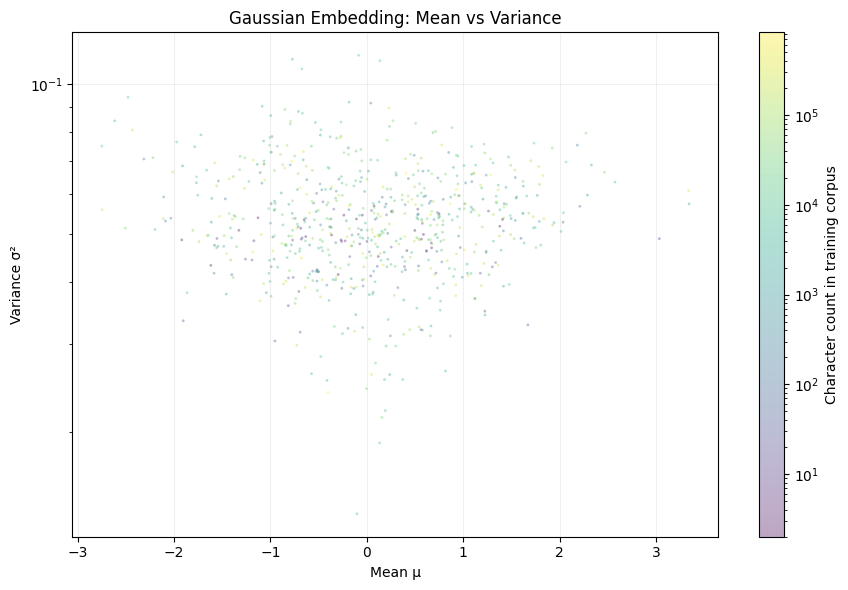

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

mu = model.embedding.mu.detach().cpu()
variance = model.embedding.std.detach().square().cpu()

# Give each of a character's embedding dimensions the same frequency colour.
counts = torch.bincount(tokens, minlength=mu.shape[0]).cpu()
point_counts = counts.repeat_interleave(mu.shape[1])

fig, ax = plt.subplots(figsize=(9, 6))
points = ax.scatter(
    mu.flatten().numpy(),
    variance.flatten().numpy(),
    c=point_counts.numpy(),
    cmap="viridis",
    norm=LogNorm(vmin=max(1, counts.min().item()), vmax=counts.max().item()),
    s=4,
    alpha=0.35,
    linewidths=0,
)

ax.set_yscale("log")
ax.set_xlabel("Mean μ")
ax.set_ylabel("Variance σ²")
ax.set_title("Gaussian Embedding: Mean vs Variance")
ax.grid(alpha=0.2)
fig.colorbar(points, ax=ax, label="Character count in training corpus")
plt.tight_layout()
plt.show()

In [ ]:
# These are training-corpus diagnostics, not held-out evaluation.
# Fixed blocks and locally seeded corruption permit paired checkpoint comparisons.
eval_generator = torch.Generator().manual_seed(1234)
eval_indices = torch.randperm(
    len(dataset), generator=eval_generator
)[:min(64, len(dataset))].tolist()
eval_blocks = torch.stack([dataset[i] for i in eval_indices])

@torch.no_grad()
def reconstruction_diagnostics(
    blocks=eval_blocks,
    timesteps=(1, 10, 100, 250, 500, 750, 1000),
    seed=1234,
):
    was_training = model.training
    model.eval()
    try:
        ids = blocks.to(device)
        noise_generator = torch.Generator().manual_seed(seed)
        def draw_noise(shape):
            return torch.randn(shape, generator=noise_generator).to(device)
        # One embedding sample reused across noise levels; never included as a CE loss target.
        x0 = model.embedding.mu[ids] + model.embedding.std[ids] * draw_noise((*ids.shape, DIM))
        clean_accuracy = (model.round_to_tokens(x0) == ids).float().mean().item()
        results = []
        for timestep in timesteps:
            if not 1 <= timestep <= DIFFUSION_STEPS:
                raise ValueError('Diagnostic timesteps must be within the training schedule')
            t = torch.full((ids.size(0),), timestep, device=device, dtype=torch.long)
            alpha = alpha_bar[t].view(-1, 1, 1)
            x_t = alpha.sqrt() * x0 + (1 - alpha).sqrt() * draw_noise(x0.shape)
            prediction = model(x_t, t)
            log_probs = model.rounding_log_probs(prediction)
            results.append({
                't': timestep,
                'token_ce': F.nll_loss(log_probs.flatten(0, 1), ids.flatten()).item(),
                'token_accuracy': (log_probs.argmax(-1) == ids).float().mean().item(),
                'raw_norm': prediction.square().mean().item(),
                'used_x0_norm': posterior_x0_mean(
                    x_t, log_probs.exp(), alpha_bar[timestep]
                ).square().mean().item(),
            })
        return {'clean_token_accuracy': clean_accuracy, 'timesteps': results}
    finally:
        model.train(was_training)


diagnostics = reconstruction_diagnostics()
print(f"Clean embedding token accuracy (diagnostic only): {diagnostics['clean_token_accuracy']:.1%}")
for row in diagnostics['timesteps']:
    print(
        f"t={row['t']:4d} | token_ce={row['token_ce']:.4f} | "
        f"token_accuracy={row['token_accuracy']:.1%} | raw_norm²/d={row['raw_norm']:.4f} | "
        f"used_x0_norm²/d={row['used_x0_norm']:.4f}"
    )
print('Embedding geometry | ' + ' | '.join(
    f'{name}={value:.4f}' for name, value in embedding_diagnostics().items()
))


Clean embedding token accuracy (diagnostic only): 99.7%
t=   1 | token_ce=0.2232 | token_accuracy=93.5% | raw_norm²/d=0.2978 | used_x0_norm²/d=1.0201
t=  10 | token_ce=0.2158 | token_accuracy=93.8% | raw_norm²/d=0.2907 | used_x0_norm²/d=1.0157
t= 100 | token_ce=0.3772 | token_accuracy=88.6% | raw_norm²/d=0.2957 | used_x0_norm²/d=0.9200
t= 250 | token_ce=1.6619 | token_accuracy=53.5% | raw_norm²/d=0.3343 | used_x0_norm²/d=0.6042
t= 500 | token_ce=3.1207 | token_accuracy=18.9% | raw_norm²/d=0.3504 | used_x0_norm²/d=0.1257
t= 750 | token_ce=3.3047 | token_accuracy=16.1% | raw_norm²/d=0.3513 | used_x0_norm²/d=0.0612
t=1000 | token_ce=3.3350 | token_accuracy=15.8% | raw_norm²/d=0.3514 | used_x0_norm²/d=0.0638
Embedding geometry | mean_avg=0.0272 | mean_rms=0.2101 | variance_avg=0.9784 | within_variance=0.0543 | between_variance=0.9241 | cov_rms_error=0.5719


In [ ]:
@torch.no_grad()
def trace_reverse(start_noise=None, reverse_steps=50, eta=None, seed=SAMPLE_SEED):
    # With default start_noise, the same seed/steps/eta reproduces sample().
    eta = sampling_eta(eta)
    if not 1 <= reverse_steps <= DIFFUSION_STEPS:
        raise ValueError('reverse_steps must be between 1 and DIFFUSION_STEPS')
    was_training = model.training
    model.eval()
    try:
        generator = torch.Generator(device='cpu').manual_seed(seed)
        if start_noise is None:
            x_t = sampling_noise(
                (SAMPLE_BATCH_SIZE, BLOCK_SIZE, DIM), model.embedding.mu, generator,
            )
        else:
            # Supplied start state: seed controls only the subsequent noise draws.
            x_t = start_noise.to(model.embedding.mu).clone()
        print(f'Posterior-mean DDIM trace | eta={eta} | seed={seed}')
        previous_x0 = None
        times = torch.linspace(DIFFUSION_STEPS, 0, reverse_steps + 1).long().tolist()
        for number, (current, next_time) in enumerate(zip(times[:-1], times[1:])):
            state_before = x_t.square().mean(dim=(1, 2))
            x_t, raw_prediction, x0_hat = reverse_step(x_t, current, next_time, eta=eta, generator=generator)
            if not torch.isfinite(x_t).all().item():
                raise FloatingPointError(f'Non-finite reverse state at timestep {next_time}')
            raw_norm = raw_prediction.square().mean(dim=(1, 2))
            used_norm = x0_hat.square().mean(dim=(1, 2))
            state_after = x_t.square().mean(dim=(1, 2))
            change = None if previous_x0 is None else (x0_hat - previous_x0).square().mean(dim=(1, 2))
            classifier_ids = model.round_to_tokens(raw_prediction).cpu()
            used_ids = model.round_to_tokens(x0_hat).cpu()
            print(f'\nstep {number} | t={current} → {next_time}')
            for i in range(x_t.size(0)):
                delta = '—' if change is None else f'{change[i].item():.6f}'
                classifier_text = ''.join(itos[token] for token in classifier_ids[i].tolist())
                used_text = ''.join(itos[token] for token in used_ids[i].tolist())
                print(
                    f'sample {i} | raw_norm²/d={raw_norm[i].item():.6f}'
                    f' | used_x0_norm²/d={used_norm[i].item():.6f}'
                    f' | state_norm²/d={state_before[i].item():.6f} → {state_after[i].item():.6f}'
                    f' | used_x0_change²/d={delta}'
                )
                print(f'  classifier argmax: {classifier_text!r}')
                print(f'  decoded x0 estimate: {used_text!r}')
            previous_x0 = x0_hat
        return model.round_to_tokens(x_t)
    finally:
        model.train(was_training)


# Set reverse_steps=SAMPLE_REVERSE_STEPS to trace the full generation schedule.
trace_tokens = trace_reverse(reverse_steps=50)


In [ ]:
checkpoint_path = Path('checkpoints/gauss_embed_dlm_wass_ce_posterior.pt')
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

# Record current default sampling settings even when changed after training.
run_config.update(ddim_eta=sampling_eta(None), sample_seed=SAMPLE_SEED,
                  sample_reverse_steps=SAMPLE_REVERSE_STEPS)

torch.save({
    'model': model.state_dict(),
    'optimizer': optimizer.state_dict(),
    'chars': chars,
    'dim': DIM,
    'config': run_config,
    'objective': OBJECTIVE,
    'completed_steps': completed_steps,
}, checkpoint_path)
print(f'Saved {checkpoint_path.resolve()} after {completed_steps} completed optimizer steps')
